In [1]:
import json

def format_json(input_file, output_file):
    with open(input_file, 'r') as f:
        data = json.load(f)
    
    with open(output_file, 'w') as f:
        json.dump(data, f, indent=4)

# Usage
input_file = './TwoTouchingCircles/metadata.json'
output_file = 'formatted_touching_circles.json'
format_json(input_file, output_file)

In [2]:
import pandas as pd
import json

# Load the data from a JSON file in the same directory
def load_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# Assume the JSON file is named 'grid_data.json'
data = load_json_data('./Grids/word_grids/word_grids_metadata.json')

# Create a list to hold the rows of our DataFrame
rows = []
prompts = [
    "Count the number of rows and columns and answer with numbers in curly brackets. For example, rows={5} columns={6}",
    "How many rows and columns are in the table? Answer with only the numbers in a pair (row,column), e.g., (5,6)."
]
for image_name, image_data in data.items():
    for prompt in prompts:
        row = {
            "task": "Counting Grid - Word Grids",
            "image_path": f"./Grids/word_grids/{image_name}",
            "prompt": prompt,
            "groundtruth": f"{image_data['rows']},{image_data['columns']}",
            "metadata": json.dumps({
                "cells": image_data["cells"],
                "image_size": image_data["image_size"],
                "linewidth": image_data["linewidth"]
            })
        }
        rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Display the DataFrame
# print(df)
df
# Optionally, save the DataFrame to a CSV file
df.to_csv("word_grids.csv", index=False)

# olympic pentagons

In [3]:
import pandas as pd
import json
from datetime import datetime

# Load the data from a JSON file in the same directory
def load_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# Assume the JSON file is named 'olympic_counting_data.json'
data = load_json_data('./OlympicLikePentagon/metadata.json')

# Create a list to hold the rows of our DataFrame
rows = []
# prompts = [
#     "How many circles are in the image? Answer with only the number in numerical format.",
#     "Count the circles in the image. Answer with a number in curly brackets e.g. {3}."
# ]

prompts = [
    "How many pentagons are in the image? Answer with only the number in numerical format.",
    "Count the pentagons in the image. Answer with a number in curly brackets e.g. {3}."
]

task_name = "Olympic_Counting_Pentagons"

for image_id, image_data in data.items():
    # Create a copy of image_data and remove 'image_id'
    metadata = image_data.copy()
    metadata.pop('image_id', None)
    
    for prompt in prompts:
        row = {
            "task": "Olympic Counting - Pentagons",
            "image_path": f"./OlympicLikePentagon/{image_id}.png",
            "prompt": prompt,
            "groundtruth": str(len(image_data['colors'])),
            "metadata": json.dumps(metadata)
        }
        rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Generate a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create the filename
filename = f"{task_name}_.csv"

# Save the DataFrame to the new CSV file
df.to_csv(filename, index=False)

print(f"Data saved to {filename}")

# Optionally, display the DataFrame
# print(df)

Data saved to Olympic_Counting_Pentagons_.csv


# olympic circles

In [4]:
import pandas as pd
import json
from datetime import datetime

# Load the data from a JSON file in the same directory
def load_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# Assume the JSON file is named 'olympic_counting_data.json'
data = load_json_data('./OlympicLikeLogo/metadata.json')

# Create a list to hold the rows of our DataFrame
rows = []
prompts = [
    "How many circles are in the image? Answer with only the number in numerical format.",
    "Count the circles in the image. Answer with a number in curly brackets e.g. {3}."
]

# prompts = [
#     "How many pentagons are in the image? Answer with only the number in numerical format.",
#     "Count the pentagons in the image. Answer with a number in curly brackets e.g. {3}."
# ]

task_name = "Olympic_Counting_Circles"

for image_id, image_data in data.items():
    # Create a copy of image_data and remove 'image_id'
    metadata = image_data.copy()
    metadata.pop('image_id', None)
    
    for prompt in prompts:
        row = {
            "task": "Olympic Counting - Circles",
            "image_path": f"./OlympicLikeLogo/{image_id}.png",
            "prompt": prompt,
            "groundtruth": str(len(image_data['colors'])),
            "metadata": json.dumps(metadata)
        }
        rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Generate a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create the filename
filename = f"{task_name}_.csv"

# Save the DataFrame to the new CSV file
df.to_csv(filename, index=False)

print(f"Data saved to {filename}")

# Optionally, display the DataFrame
# print(df)

Data saved to Olympic_Counting_Circles_.csv


In [5]:
import pandas as pd
import json
from datetime import datetime

# Load the data from a JSON file in the same directory
def load_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

data = load_json_data('./formatted_touching_circles.json')

# Create a list to hold the rows of our DataFrame
rows = []

prompts = [
    "Are the two circles touching each other? Answer with Yes/No.",
    "Are the two circles overlapping? Answer with Yes/No."
]

task_name = "Touching_Circles"

for image_id, image_data in data.items():
    
    # Create a copy of image_data and remove 'image_id'
    metadata = image_data.copy()
    metadata.pop('image_id', None)
    
    for prompt in prompts:
        # touching
        if prompt == prompts[0] and image_data['distance'] <= 0:
            gt = 'Yes'
        elif prompt == prompts[0] and image_data['distance'] > 0:
            gt = 'No'
            
        # Overlapping
        if prompt == prompts[1] and image_data['distance'] < 0:
            gt = 'Yes'
        elif prompt == prompts[1] and image_data['distance'] >= 0:
            gt = 'No'
            
        row = {
            "task": "Touching Circles",
            "image_path": f"./TwoTouchingCircles/{image_id}.png",
            "prompt": prompt,
            "groundtruth": gt,
            "metadata": json.dumps(metadata)
        }
        rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Generate a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create the filename
filename = f"{task_name}.csv"

# Save the DataFrame to the new CSV file
df.to_csv(filename, index=False)

print(f"Data saved to {filename}")

# Optionally, display the DataFrame
# print(df)

Data saved to Touching_Circles.csv


In [6]:
import pandas as pd
import json

# Load the data from a JSON file in the same directory
def load_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# Assume the JSON file is named 'olympic_counting_data.json'
data = load_json_data('./LinePlotIntersection/configurations.json')

# Create a list to hold the rows of our DataFrame
rows = []

prompts = [
    "How many times do the blue and red line plots cross each other?",
    "How many times do the blue and red lines intersect?"
]

task_name = "Line_Plot_Intersection"

for image_id, image_data in data.items():
    # Create a copy of image_data and remove 'image_id'
    metadata = image_data.copy()
    metadata.pop('num_intersections', None)
    
    for prompt in prompts:
        row = {
            "task": "Line Plot Intersections",
            "image_path": f"./LinePlotIntersection/{image_id}",
            "prompt": prompt,
            "groundtruth": str(image_data['num_intersections']),
            "metadata": json.dumps(metadata)
        }
        rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Generate a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create the filename
filename = f"{task_name}.csv"

# Save the DataFrame to the new CSV file
df.to_csv(filename, index=False)

print(f"Data saved to {filename}")

# Optionally, display the DataFrame
# print(df)

Data saved to Line_Plot_Intersection.csv


In [8]:
import pandas as pd
import json

# Load the data from a JSON file in the same directory
def load_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# Load the JSON file
data = load_json_data('./NestedSquares/configurations.json')

print(f"Loaded data from './NestedSquares/configurations.json'")
print(f"Number of items in data: {len(data)}")
print("Structure of the first item:")
print(json.dumps(data[0], indent=2))

# Create a list to hold the rows of our DataFrame
rows = []

prompts = [
    "Count the total number of squares in the image.",
    "How many squares are in the image?"
]

task_name = "Nested_Squares"

for image_data in data:
    # Get the image_name and remove it from metadata
    image_name = image_data.pop('image_name')
    # Get the depth and remove it from metadata
    depth = image_data.pop('depth')
    
    # The rest of the data becomes metadata
    metadata = image_data
    
    for prompt in prompts:
        row = {
            "task": "Nested Squares",
            "image_path": f"./NestedSquares/{image_name}",
            "prompt": prompt,
            "groundtruth": str(depth),
            "metadata": json.dumps(metadata)
        }
        rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Create the filename
filename = f"{task_name}.csv"

# Save the DataFrame to the new CSV file
df.to_csv(filename, index=False)

print(f"Data saved to {filename}")


Loaded data from './NestedSquares/configurations.json'
Number of items in data: 120
Structure of the first item:
{
  "image_name": "nested_squares_depth_2_image_1_thickness_2.png",
  "depth": 2,
  "center": [
    -2.2395532434656262,
    -2.245365217594155
  ],
  "initial_size": 17.5741566495224,
  "reduction_factor": 0.75,
  "line_thickness": 2,
  "padding": 0.75,
  "squares": [
    {
      "center": [
        -2.2395532434656262,
        -2.245365217594155
      ],
      "size": 17.5741566495224
    },
    {
      "center": [
        -0.3660647610609251,
        -0.5628543028406385
      ],
      "size": 12.4306174871418
    }
  ]
}
Data saved to Nested_Squares.csv


In [33]:
import pandas as pd
import json
import re

# Load the data from a JSON file in the same directory
def load_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)
    
# Load the JSON file
data = load_json_data('./SubwayMaps/metadata.json')


# Create a list to hold the rows of our DataFrame
rows = []



task_name = "Subway Connections"

for graph in data:
    # print(graph['name'])
    prompts = set()
    metadata = graph.copy()
    graph_name = metadata.pop('name')
    num_paths = metadata.pop('path_outs')
    for connect in graph['connections']:

        pointA = connect['start']
        pointB = connect['end']


        
        question1 = f"How many single-color paths go from {pointA} to {pointB}? Answer with a number in curly brackets e.g. " + "{{3}}".format()
        question2 = f"Count the one-colored routes that go from {pointA} to {pointB}. Answer with a number in curly brackets e.g. " + "{{3}}".format()
        prompts.add(question1)
        prompts.add(question2)
    
    for prompt in prompts:
        row = {
            "task:": "Subway Connections",
            "image_path": f"./SubwayMaps/{graph_name}.png",
            "prompt": prompt,
            "groundtruth": num_paths,
            "metadata": json.dumps(metadata)
        }
        rows.append(row)
        
df = pd.DataFrame(rows)
df.to_csv("Subway_Connections.csv", index=False)
    # print(num_paths, list(prompts))
    # print('\n')

# for image_data in data:
#     # Get the image_path
#     image_path = image_data['image_path']
    
#     # Create a copy of image_data for metadata
#     metadata = image_data.copy()
    
#     for prompt in prompts:
#         path = image_path.replace("./images", "./CircledLetter")
#         row = {
#             "task": "Circled Letter",
#             "image_path": path,
#             "prompt": prompt,
#             "groundtruth": image_data['word'][image_data['circle_index']],
#             "metadata": json.dumps(metadata)
#         }
#         rows.append(row)

# Create the DataFrame
# df = pd.DataFrame(rows)

# # Create the filename
# filename = f"{task_name}_tHyUiKaRbNqWeOpXcZvM.csv"

# # Save the DataFrame to the new CSV file
# df.to_csv(filename, index=False)

# print(f"Data saved to {filename}")


# Combine individual task CSVs

In [7]:
import os
import pandas as pd
import glob
from datasets import Dataset, Image

def preprocess_groundtruth(value):
    if pd.isna(value):
        return "Unknown"
    elif isinstance(value, (int, float)):
        return str(int(value))
    else:
        return str(value)

def combine_csv_files(input_dir='./extracted_csv_files', output_file='combined_output.csv'):
    if not os.path.exists(input_dir):
        raise FileNotFoundError(f"The directory {input_dir} does not exist.")
    
    all_files = glob.glob(os.path.join(input_dir, '**', '*.csv'), recursive=True)
    
    if not all_files:
        print(f"No CSV files found in {input_dir} or its subdirectories")
        return None
    
    df_list = []
    
    for filename in all_files:
        print(f"Reading {filename}")
        df = pd.read_csv(filename, index_col=None, header=0)
        df_list.append(df)
    
    combined_df = pd.concat(df_list, axis=0, ignore_index=True)
    
    # Preprocess the 'groundtruth' column
    if 'groundtruth' in combined_df.columns:
        combined_df['groundtruth'] = combined_df['groundtruth'].apply(preprocess_groundtruth)
    
    output_path = os.path.join(os.getcwd(), output_file)
    combined_df.to_csv(output_path, index=False)
    
    print(f"Combined CSV file saved as {output_path}")
    print(f"Total number of CSV files combined: {len(all_files)}")
    
    return combined_df

# Combine CSV files
combined_df = combine_csv_files()

# Create Dataset
dataset = Dataset.from_pandas(combined_df)

# Cast 'image_path' column to Image type
if 'image_path' in dataset.column_names:
    dataset = dataset.cast_column('image_path', Image())

print(dataset)

Reading ./extracted_csv_files/Subway_Connections.csv
Reading ./extracted_csv_files/Nested_Squares.csv
Reading ./extracted_csv_files/Line_Plot_Intersection.csv
Reading ./extracted_csv_files/Touching_Circles.csv
Reading ./extracted_csv_files/grids/word_grids.csv
Reading ./extracted_csv_files/grids/blank_grids.csv
Reading ./extracted_csv_files/olympic_counting/Olympic_Counting_Circles.csv
Reading ./extracted_csv_files/olympic_counting/Olympic_Counting_Pentagons_.csv
Reading ./extracted_csv_files/circled_letter/Circled_Letter_Subdermatoglyphic.csv
Reading ./extracted_csv_files/circled_letter/Circled_Letter_tHyUiKaRbNqWeOpXcZvM.csv
Reading ./extracted_csv_files/circled_letter/Circled_Letter_Acknowledgement.csv
Combined CSV file saved as /Users/log/Github/BlindLLMs/datasets/combined_output.csv
Total number of CSV files combined: 11
Dataset({
    features: ['task:', 'image_path', 'prompt', 'groundtruth', 'metadata', 'task'],
    num_rows: 6868
})


In [6]:
# len(combined_df['groundtruth'].unique())
# combined_df['task'].unique()
# big_df = pd.read.dataset(dataset)
mask_df = combined_df[combined_df['task'] == 'Subway Connections']
print(mask_df['prompt'].unique())
print(dataset['task'])

[]
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 

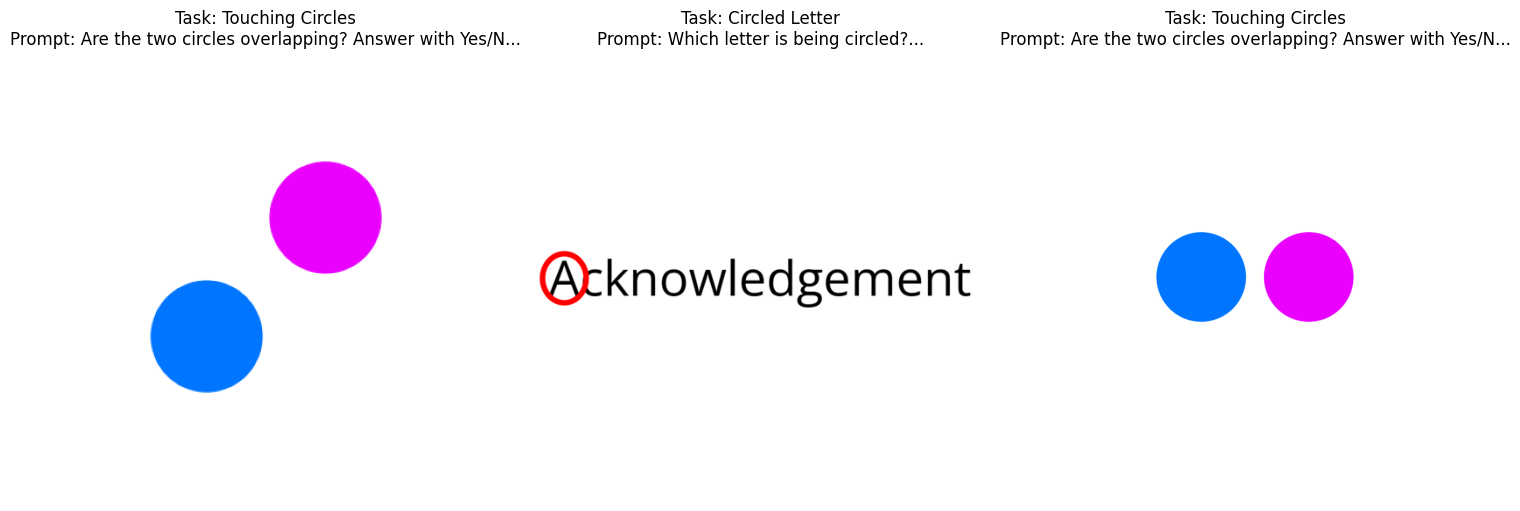

Random example (index 1252):
task: Touching Circles
image_path: <Image object>
prompt: Are the two circles touching each other? Answer with Yes/No.
groundtruth: No
metadata: {"diameter": 0.2, "center_1": [0.395, 0.5], "center_2": [0.605, 0.5], "distance": 0.05000000000000001, "rotation": "horizontal", "dpi": 100, "canvas_size": 5.0}


In [14]:
import matplotlib.pyplot as plt
from datasets import Dataset, Image
import random

# Assuming your dataset is already created and named 'dataset'

def show_random_images(dataset, num_images=3):
    # Get random indices
    random_indices = random.sample(range(len(dataset)), num_images)
    
    # Create a figure with subplots
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))
    
    for i, idx in enumerate(random_indices):
        # Get the image and its metadata
        example = dataset[idx]
        image = example['image_path']
        task = example['task']
        prompt = example['prompt']
        
        # Display the image
        if num_images > 1:
            ax = axes[i]
        else:
            ax = axes
        ax.imshow(image.convert('RGB'))
        ax.axis('off')
        ax.set_title(f"Task: {task}\nPrompt: {prompt[:50]}...")
    
    plt.tight_layout()
    plt.show()

# Show 3 random images from the dataset
show_random_images(dataset, num_images=3)

# Optional: Print some information about a random example
random_idx = random.randint(0, len(dataset)-1)
print(f"Random example (index {random_idx}):")
for key, value in dataset[random_idx].items():
    if key != 'image_path':
        print(f"{key}: {value}")
    else:
        print(f"{key}: <Image object>")

In [64]:
dataset.push_to_hub("XAI/vlmsareblind")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/6332 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/64 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/XAI/vlmsareblind/commit/29508580b97588a6bab5fbcebe264368369822d8', commit_message='Upload dataset', commit_description='', oid='29508580b97588a6bab5fbcebe264368369822d8', pr_url=None, pr_revision=None, pr_num=None)

# Verify

In [15]:
import pandas as pd
import json
from collections import defaultdict


DPI value counts for 'Touching Circles' task:


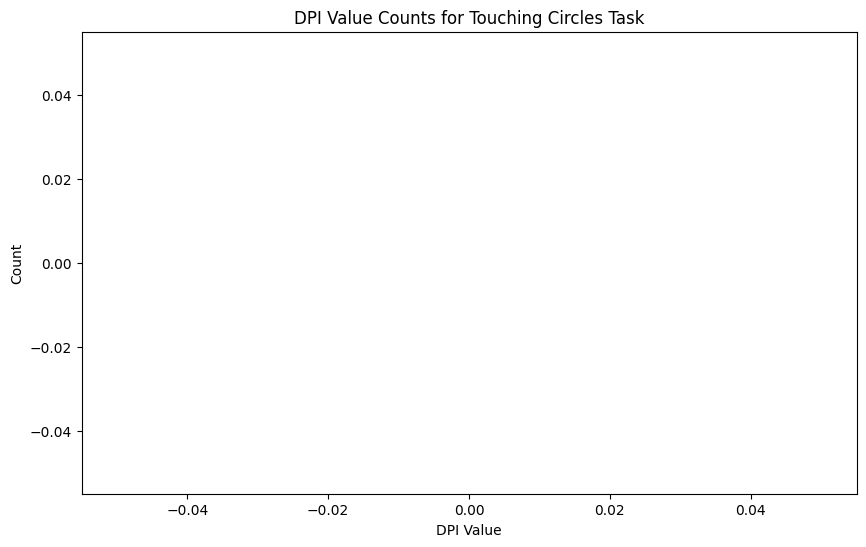

,Count
DPI,


In [16]:
import pandas as pd
import json
from collections import defaultdict
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('combined_output.csv')

# Filter for 'Touching Circles' task
task_df = df[df['task'] == 'Nested Squares']

def count_dpi_values(df):
    dpi_counts = defaultdict(int)
    
    for _, row in df.iterrows():
        try:
            # Parse the JSON data in the 'metadata' column
            metadata = json.loads(row['metadata'])
            # Extract and count the DPI value
            dpi = metadata.get('dpi')
            if dpi is not None:
                dpi_counts[dpi] += 1
        except json.JSONDecodeError:
            print(f"Error parsing JSON for row: {row.name}")
    
    return dict(dpi_counts)

# Count DPI values
dpi_counts = count_dpi_values(task_df)

# Display results
print("\nDPI value counts for 'Touching Circles' task:")
for dpi, count in sorted(dpi_counts.items()):
    print(f"DPI {dpi}: {count} occurrences")

# Create a bar plot of DPI counts
plt.figure(figsize=(10, 6))
plt.bar(dpi_counts.keys(), dpi_counts.values())
plt.title('DPI Value Counts for Touching Circles Task')
plt.xlabel('DPI Value')
plt.ylabel('Count')
plt.show()

# Create a DataFrame from the DPI counts for easy viewing
dpi_df = pd.DataFrame.from_dict(dpi_counts, orient='index', columns=['Count'])
dpi_df.index.name = 'DPI'
dpi_df.sort_index(inplace=True)
display(dpi_df)

### problems with olympic counting

In [17]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('combined_output.csv')

# Filter for 'Touching Circles' task
task_df = df[df['task'] == 'Subway Connections']

# gt = task_df['image_path'].value_counts()
# sort gt
# gt = gt.sort_index()/2
# print(gt)
task_df.nunique()

task             1
image_path     180
prompt           8
groundtruth      3
metadata       180
dtype: int64

# good
- Nested Squares
- Circled Word
- Two Touching Circles
- grids
# Not good 
- Line intersections
- Olympic Counting

# Line intersections
- 0: 26
- 1: 83
- 2 41

In [18]:
len('Acknowledgement')

15


Line thickness counts for 'Nested Squares' task:
Line thickness 512: 268 occurrences
Line thickness 1024: 268 occurrences


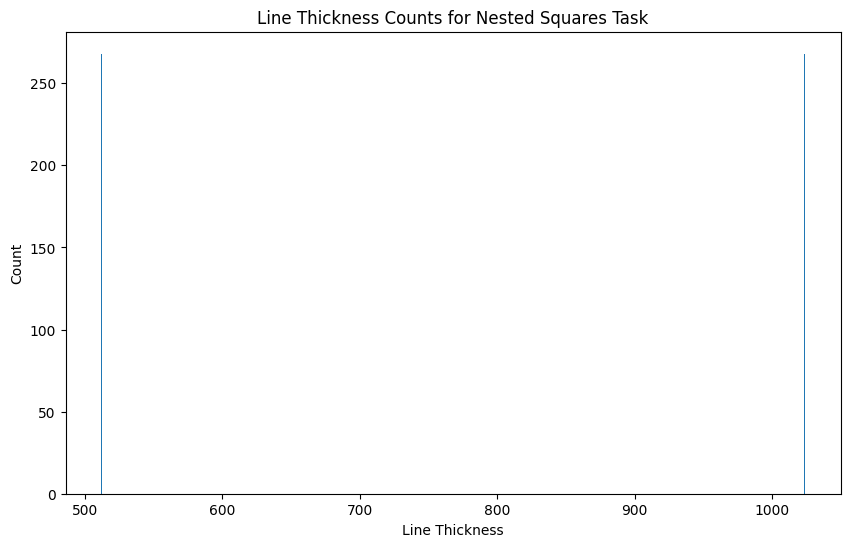

,Count
Line Thickness,
512,268
1024,268


In [19]:
import pandas as pd
import json
from collections import defaultdict
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('combined_output.csv')

# Filter for 'Nested Squares' task
task_df = df[df['task'] == 'Subway Connections']

def count_line_thickness_values(df):
    thickness_counts = defaultdict(int)
    
    for _, row in df.iterrows():
        try:
            # Parse the JSON data in the 'metadata' column
            metadata = json.loads(row['metadata'])
            # Extract and count the line_thickness value
            thickness = metadata.get('size')
            if thickness is not None:
                thickness_counts[thickness] += 1
        except json.JSONDecodeError:
            print(f"Error parsing JSON for row: {row.name}")
    
    return dict(thickness_counts)

# Count line thickness values
thickness_counts = count_line_thickness_values(task_df)

# Display results
print("\nLine thickness counts for 'Nested Squares' task:")
for thickness, count in sorted(thickness_counts.items()):
    print(f"Line thickness {thickness}: {count} occurrences")

# Create a bar plot of line thickness counts
plt.figure(figsize=(10, 6))
plt.bar(thickness_counts.keys(), thickness_counts.values())
plt.title('Line Thickness Counts for Nested Squares Task')
plt.xlabel('Line Thickness')
plt.ylabel('Count')
plt.show()

# Create a DataFrame from the line thickness counts for easy viewing
thickness_df = pd.DataFrame.from_dict(thickness_counts, orient='index', columns=['Count'])
thickness_df.index.name = 'Line Thickness'
thickness_df.sort_index(inplace=True)
display(thickness_df)

In [116]:
import os

# Set the variables
model = "claude_3_5"
source_suffix = "corrects"
dest_suffix = "correct"
overlap_prefix = "overlap"
overlap_folder = "overlapping"

# Construct the paths
source_path = f"/Users/log/Github/vision-llms-are-blind/src/TouchingCircle/images/sonnet-3.5-{source_suffix}"
dest_path = f"/Users/log/Github/vision-llms-are-blind/src/TouchingCircle/images/{model}/{overlap_folder}-prompt/{dest_suffix}"

# Create the destination directory if it doesn't exist
os.makedirs(dest_path, exist_ok=True)

# Construct and execute the move command
move_command = f"""
mv {source_path}/{model}_{overlap_prefix}_pixels_*_rotation_*_diameter_*_distance_*.png {dest_path}/
"""

# Execute the command
!{move_command}

print(f"Moved files from {source_path} to {dest_path}")

Moved files from /Users/log/Github/vision-llms-are-blind/src/TouchingCircle/images/sonnet-3.5-corrects to /Users/log/Github/vision-llms-are-blind/src/TouchingCircle/images/claude_3_5/overlapping-prompt/correct


In [123]:
import os
import shutil

# Base paths
base_paths = [
    "/Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/Which character is being highlighted with a red oval?/",
    "/Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/Which letter is being circled?/"
]

# Models and their corresponding folders
models = {
    "Gemini-1.5-Pro": ["Gemini-1.5-Pro__correct", "Gemini-1.5-Pro__wrong"],
    "GPT-4o": ["GPT-4o__correct", "GPT-4o__wrong"],
    "Sonnet": ["Sonnet__correct", "Sonnet__wrong"],
    "Sonnet-3.5": ["Sonnet-3.5__correct", "Sonnet-3.5__wrong"]
}

for base_path in base_paths:
    question = os.path.basename(os.path.normpath(base_path))
    acknowledgement_path = os.path.dirname(os.path.dirname(base_path))
    
    for model, folders in models.items():
        for folder in folders:
            # Determine if it's correct or incorrect
            category = "correct" if "_correct" in folder else "incorrect"
            
            # Source and destination paths
            src_path = os.path.join(base_path, folder)
            dst_path = os.path.join(acknowledgement_path, model, question, category)
            
            # Create destination directory if it doesn't exist
            os.makedirs(dst_path, exist_ok=True)
            
            # Move files if source directory exists
            if os.path.exists(src_path):
                for file in os.listdir(src_path):
                    src_file = os.path.join(src_path, file)
                    dst_file = os.path.join(dst_path, file)
                    shutil.move(src_file, dst_file)
                print(f"Moved files from {src_path} to {dst_path}")
            else:
                print(f"Source directory does not exist: {src_path}")

# Remove empty directories
for base_path in base_paths:
    for root, dirs, files in os.walk(os.path.dirname(base_path), topdown=False):
        for dir in dirs:
            dir_path = os.path.join(root, dir)
            if not os.listdir(dir_path):
                os.rmdir(dir_path)
                print(f"Removed empty directory: {dir_path}")

print("File movement and directory cleanup completed.")

Moved files from /Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/Which character is being highlighted with a red oval?/Gemini-1.5-Pro__correct to /Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/Gemini-1.5-Pro/Which character is being highlighted with a red oval?/correct
Moved files from /Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/Which character is being highlighted with a red oval?/Gemini-1.5-Pro__wrong to /Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/Gemini-1.5-Pro/Which character is being highlighted with a red oval?/incorrect
Moved files from /Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/Which character is being highlighted with a red oval?/GPT-4o__correct to /Users/log/Github/vision-llms-are-blind/src/CircledWord/images/tHyUiKaRbNqWeOpXcZvM/GPT-4o/Which character is being highlighted with a red o

In [126]:
import os
import shutil

# Base path
base_path = "/Users/log/Github/vision-llms-are-blind/src/LineIntersection/images/lineintersection"

# Intersection folders
intersection_folders = ["intersections_0", "intersections_1", "intersections_2"]

# Questions
questions = [
    "How many times do the blue and red line plots cross each other?",
    "How many times do the blue and red lines intersect?"
]

# Models and their corresponding folders
models = {
    "Gemini-1.5-Pro": ["Gemini-1.5-Pro__correct", "Gemini-1.5-Pro__wrong"],
    "gpt-4o": ["gpt-4o__correct", "gpt-4o__wrong"],
    "Sonnet": ["Sonnet__correct", "Sonnet__wrong"],
    "Sonnet-3.5": ["Sonnet-3.5__correct", "Sonnet-3.5__wrong"]
}

for intersection_folder in intersection_folders:
    for question in questions:
        for model, folders in models.items():
            for folder in folders:
                # Determine if it's correct or incorrect
                category = "correct" if "__correct" in folder else "incorrect"
                
                # Source and destination paths
                src_path = os.path.join(base_path, intersection_folder, question, folder)
                dst_path = os.path.join(base_path, intersection_folder, question, model, category)
                
                # Create destination directory if it doesn't exist
                os.makedirs(dst_path, exist_ok=True)
                
                # Move files if source directory exists
                if os.path.exists(src_path):
                    for file in os.listdir(src_path):
                        src_file = os.path.join(src_path, file)
                        dst_file = os.path.join(dst_path, file)
                        shutil.move(src_file, dst_file)
                    print(f"Moved files from {src_path} to {dst_path}")
                else:
                    print(f"Source directory does not exist: {src_path}")

# Remove empty directories
for root, dirs, files in os.walk(base_path, topdown=False):
    for dir in dirs:
        dir_path = os.path.join(root, dir)
        if not os.listdir(dir_path):
            os.rmdir(dir_path)
            print(f"Removed empty directory: {dir_path}")

print("File movement and directory cleanup completed.")

Moved files from /Users/log/Github/vision-llms-are-blind/src/LineIntersection/images/lineintersection/intersections_0/How many times do the blue and red line plots cross each other?/Gemini-1.5-Pro__correct to /Users/log/Github/vision-llms-are-blind/src/LineIntersection/images/lineintersection/intersections_0/How many times do the blue and red line plots cross each other?/Gemini-1.5-Pro/correct
Moved files from /Users/log/Github/vision-llms-are-blind/src/LineIntersection/images/lineintersection/intersections_0/How many times do the blue and red line plots cross each other?/Gemini-1.5-Pro__wrong to /Users/log/Github/vision-llms-are-blind/src/LineIntersection/images/lineintersection/intersections_0/How many times do the blue and red line plots cross each other?/Gemini-1.5-Pro/incorrect
Moved files from /Users/log/Github/vision-llms-are-blind/src/LineIntersection/images/lineintersection/intersections_0/How many times do the blue and red line plots cross each other?/gpt-4o__correct to /User

In [127]:
import os
import shutil
import pandas as pd

# Base paths
source_path = os.path.expanduser("/Users/log/Github/BlindLLMs/datasets/NestedSquares")
destination_base_path = os.path.expanduser("/Users/log/Github/vision-llms-are-blind/src/NestedSquares/images")  # You can change this to your preferred destination

# Read the CSV file
csv_file_path = "/Users/log/Github/BlindLLMs/datasets/nested_squares_all.csv"  # Update this with the actual path to your CSV file
df = pd.read_csv(csv_file_path)

# Ensure the destination base directory exists
os.makedirs(destination_base_path, exist_ok=True)

# Process each row in the DataFrame
for index, row in df.iterrows():
    image_name = row['image_name']
    is_correct = row['is_correct']
    model = row['Model']
    
    # Determine the correct subfolder
    subfolder = "correct" if str(is_correct).lower() == 'true' else "incorrect"
    
    # Construct source and destination paths
    source_file = os.path.join(source_path, image_name)
    destination_folder = os.path.join(destination_base_path, model, subfolder)
    destination_file = os.path.join(destination_folder, image_name)
    
    # Create the destination folder if it doesn't exist
    os.makedirs(destination_folder, exist_ok=True)
    
    # Copy the file
    if os.path.exists(source_file):
        shutil.copy2(source_file, destination_file)
        print(f"Copied {image_name} to {destination_folder}")
    else:
        print(f"Warning: {image_name} not found in source directory")

print("Image copying completed.")

Copied nested_squares_depth_2_image_1_thickness_2.png to /Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/Sonnet/correct
Copied nested_squares_depth_2_image_1_thickness_3.png to /Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/Sonnet/correct
Copied nested_squares_depth_2_image_1_thickness_4.png to /Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/Sonnet/correct
Copied nested_squares_depth_2_image_2_thickness_2.png to /Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/Sonnet/correct
Copied nested_squares_depth_2_image_2_thickness_3.png to /Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/Sonnet/correct
Copied nested_squares_depth_2_image_2_thickness_4.png to /Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/Sonnet/correct
Copied nested_squares_depth_2_image_3_thickness_2.png to /Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/Sonnet/correct
Copied nested_squares_depth_2_image_3_thi

# Nested Squares   

In [130]:
import pandas as pd
import pickle

# turn pkl into csv

path = '/Users/log/Github/BlindLLMs/datasets/NestedSquares/export_nested_squares_all_rerun_both_prompts.pkl'

# Load the pickle file
with open(path, 'rb') as f:
    data = pickle.load(f)

# Convert the data to a DataFrame
df = pd.DataFrame(data)

# Save the DataFrame as a CSV file
csv_file_path = '/Users/log/Github/BlindLLMs/datasets/NestedSquares/nested_both_prompts.csv'
df.to_csv(csv_file_path, index=False)

print(f"Converted {path} to {csv_file_path}")

Converted /Users/log/Github/BlindLLMs/datasets/NestedSquares/export_nested_squares_all_rerun_both_prompts.pkl to /Users/log/Github/BlindLLMs/datasets/NestedSquares/nested_both_prompts.csv


In [138]:
import os
import pandas as pd
import shutil

# Load the CSV file
csv_file = '/Users/log/Github/BlindLLMs/datasets/NestedSquares/nested_both_prompts.csv'
df = pd.read_csv(csv_file)

# Source folder where images are currently stored
source_folder = '/Users/log/Github/BlindLLMs/datasets/NestedSquares/'

# Root destination path for organized images
root_dest_path = '/Users/log/Github/vision-llms-are-blind/src/NestedSquares/images/'

# Function to create directory if it doesn't exist
def create_directory(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Iterate over each row in the DataFrame
for index, row in df.iterrows():
    # Extract relevant information from the row
    image_name = row['image_name']
    prompt_format = row['prompt_format']
    model = row['Model']
    is_correct = 'correct' if row['is_correct'] else 'incorrect'
    
    # Construct the destination path
    dest_path = os.path.join(root_dest_path, prompt_format, model, is_correct)
    
    # Create the destination directory if it doesn't exist
    create_directory(dest_path)
    
    # Construct the full source and destination file paths
    source_file = os.path.join(source_folder, image_name)
    dest_file = os.path.join(dest_path, image_name)
    
    # Copy the file to the new location
    shutil.copy2(source_file, dest_file)

print("Images have been copied successfully.")


Images have been copied successfully.


In [141]:
import pandas as pd

# Load the CSV file
csv_file = '/Users/log/Github/BlindLLMs/datasets/NestedSquares/nested_both_prompts.csv'
df = pd.read_csv(csv_file)

# Add a column for correctness as integers
df['correct_int'] = df['is_correct'].apply(lambda x: 1 if x else 0)

# Group by model and line thickness and calculate accuracy
accuracy_df = df.groupby(['Model', 'line_thickness']).agg(
    total_count=('correct_int', 'count'),
    correct_count=('correct_int', 'sum')
).reset_index()

accuracy_df['accuracy'] = accuracy_df['correct_count'] / accuracy_df['total_count']

# Save the accuracy DataFrame to a CSV file
output_csv = '/Users/log/Github/BlindLLMs/datasets/NestedSquares/model_accuracy_by_line_width.csv'
accuracy_df.to_csv(output_csv, index=False)

print("Accuracy calculations completed and saved to model_accuracy_by_line_width.csv.")


Accuracy calculations completed and saved to model_accuracy_by_line_width.csv.


# most common incorrect

## nested squares - most common incorrect

In [145]:
import pandas as pd

df = pd.read_csv('/Users/log/Github/BlindLLMs/datasets/NestedSquares/nested_both_prompts.csv')
incorrect_counts = df.groupby(['image_name', 'prompt'])['is_correct'].apply(lambda x: (x == False).sum()).reset_index()
incorrect_counts.columns = ['image_name', 'prompt', 'incorrect_count']

incorrect_counts.to_csv('/Users/log/Github/BlindLLMs/datasets/NestedSquares/incorrect_counts.csv', index=False)

## circled letter - most common incorrect

In [147]:
import os
from collections import defaultdict
from pathlib import Path

def analyze_errors(base_path):
    results = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    
    for word in os.listdir(base_path):
        word_path = os.path.join(base_path, word)
        if not os.path.isdir(word_path):
            continue
        
        for model in os.listdir(word_path):
            model_path = os.path.join(word_path, model)
            if not os.path.isdir(model_path):
                continue
            
            for prompt in os.listdir(model_path):
                prompt_path = os.path.join(model_path, prompt)
                if not os.path.isdir(prompt_path):
                    continue
                
                incorrect_path = os.path.join(prompt_path, 'incorrect')
                if not os.path.exists(incorrect_path):
                    continue
                
                for image in os.listdir(incorrect_path):
                    results[word][prompt][image] += 1
    
    return results

def print_top_errors(results, top_n=7):
    for word in results:
        print(f"\nWord: {word}")
        for prompt in results[word]:
            print(f"  Prompt: {prompt}")
            sorted_images = sorted(results[word][prompt].items(), key=lambda x: x[1], reverse=True)
            for image, count in sorted_images[:top_n]:
                print(f"    {image}: {count} errors")

# Usage
base_path = "/Users/log/Github/vision-llms-are-blind/src/CircledWord/images"
results = analyze_errors(base_path)
print_top_errors(results)


Word: Subdermatoglyphic
  Prompt: Which character is being highlighted with a red oval
    text_image_4ee4fd8b-6af2-4b9e-9a4d-b2ef2e1ade30.png: 3 errors
    text_image_434a8cc9-8491-4b07-a010-eed386c637e1.png: 3 errors
    text_image_74e5127e-bd0b-4450-9810-902f1f9c6ed2.png: 3 errors
    text_image_7abce362-9616-4c8b-8bb0-6bf25d0a086e.png: 3 errors
    text_image_ba429942-e8c4-40ae-8c5d-284c2b22311b.png: 3 errors
    text_image_17d400fd-b17e-42c9-8730-eb71e87c597f.png: 3 errors
    text_image_8105c3b9-a5e3-402d-930d-970392e7f49d.png: 3 errors
  Prompt: Which letter is being circled
    text_image_74e5127e-bd0b-4450-9810-902f1f9c6ed2.png: 3 errors
    text_image_367df555-52d6-4686-8e13-2ce0aec0dfb7.png: 3 errors
    text_image_ba429942-e8c4-40ae-8c5d-284c2b22311b.png: 3 errors
    text_image_18889612-124a-463a-93f3-378a690e1295.png: 3 errors
    text_image_17d400fd-b17e-42c9-8730-eb71e87c597f.png: 3 errors
    text_image_c9e7a6da-8a14-4e51-98ce-64ace9abe798.png: 3 errors
    text_image